In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests


In [2]:
url = "https://api.binance.com/api/v3/klines"
res = requests.get(url, params={"symbol": "BTCUSDT", "interval": "1d", "limit": "1"}).json()

print("list type: ", type(res))
print("list length: ", len(res))

for index, value in enumerate(res[0]):
    print(f"Position: [{index}]: {value} (type: {type(value).__name__}")


list type:  <class 'list'>
list length:  1
Position: [0]: 1790380800000 (type: int
Position: [1]: 84100.00000000 (type: str
Position: [2]: 84145.26000000 (type: str
Position: [3]: 83798.00000000 (type: str
Position: [4]: 84000.00000000 (type: str
Position: [5]: 1257.21579000 (type: str
Position: [6]: 1790467199999 (type: int
Position: [7]: 105592530.96927980 (type: str
Position: [8]: 164234 (type: int
Position: [9]: 557.23184000 (type: str
Position: [10]: 46797592.50304650 (type: str
Position: [11]: 0 (type: str


findfont: Failed to find font weight medium, now using 400.
findfont: Failed to find font weight semibold, now using 700.
findfont: Failed to find font weight semibold, now using 700.


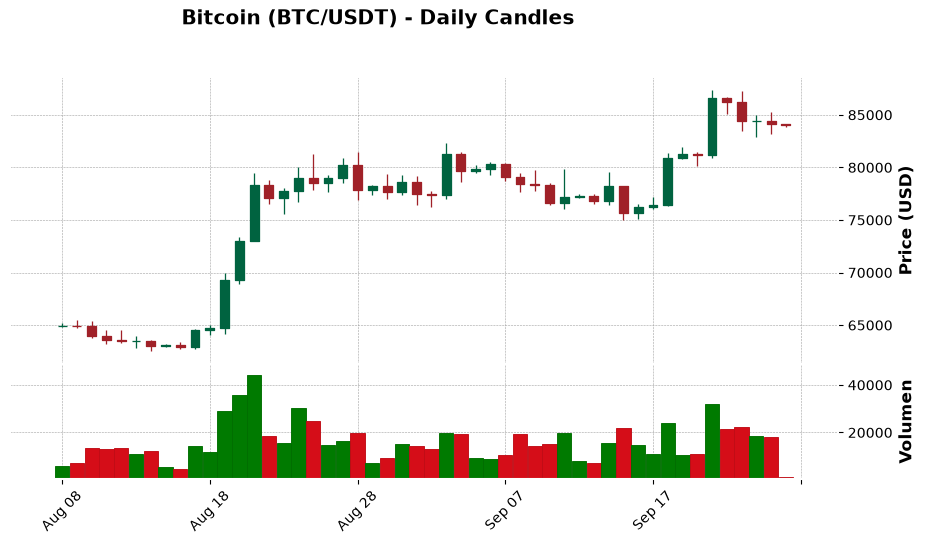

In [3]:
import mplfinance as mpf

url = "https://api.binance.com/api/v3/klines"
params = {"symbol": "BTCUSDT", "interval": "1d", "limit": 50}
data = requests.get(url, params=params).json()

columns = [
    "open_time", "open", "high", "low", "close", "volume",
    "close_time", "qav", "trades", "taker_buy_vol", "tbq", "ignore"
]

df = pd.DataFrame(data, columns=columns)

numeric_cols = ["open", "high", "low", "close", "volume"]
df[numeric_cols] = df[numeric_cols].astype(float)

#REQUISITO CLAVE DE MPLFINANCE:
# El índice del DataFrame debe ser de tipo Fecha (DatetimeIndex)
df["date"] = pd.to_datetime(df["open_time"], unit="ms")
df.set_index("date", inplace=True)

#Chart 
mpf.plot(
    df, 
    type="candle",          
    style="charles",        # traditional colors (Green/Rojo)
    title="Bitcoin (BTC/USDT) - Daily Candles",
    ylabel="Price (USD)",
    volume=True,            # Show volume bars down
    ylabel_lower="Volumen",
    figratio=(12, 6)
)

In [4]:
df["close"] = df["close"].astype(float)
df["tbq"] = df["tbq"].astype(float)
df["taker_buy_vol"] = df["taker_buy_vol"].astype(float)

df["Volume"] = df["volume"].astype(float) * df["close"] /1_000_000
df["taker_buy"] = df["taker_buy_vol"].astype(float) * df["close"] /1_000_000

df["buy_pressure"] = (df["taker_buy_vol"] / df["volume"].astype(float)) * 100
df["sell_pressure"] = 100 - df["buy_pressure"]

df_display = pd.DataFrame({
    "Close ($)": df["close"].round(2),
    "Total volume ($M)": df["Volume"].round(2),
    "Taker Buy ($M)": df["taker_buy"].round(2),
    "Buy pressure (%)": df["buy_pressure"].round(2),
    "Sell pressure (%)": df["sell_pressure"].round(2)
})

df_display.tail()


,Close ($),Total volume ($M),Taker Buy ($M),Buy pressure (%),Sell pressure (%)
date,,,,,
2026-09-22,86208.56,1838.70,817.71,44.47,55.53
2026-09-23,84397.60,1869.49,872.22,46.66,53.34
2026-09-24,84410.24,1578.78,742.60,47.04,52.96
2026-09-25,84099.99,1518.53,718.31,47.30,52.70
2026-09-26,84000.01,105.61,46.81,44.32,55.68


In [5]:
import requests
import pandas as pd

# Endpoint Binance Futures
url_futures = "https://fapi.binance.com/fapi/v1/klines"
params = {"symbol": "BTCUSDT", "interval": "1d", "limit": 1}

data_f = requests.get(url_futures, params=params).json()
df_f = pd.DataFrame(data_f)

columns = [
    "open_time", "open", "high", "low", "close", "volume",
    "close_time", "qav", "trades", "taker_buy_vol", "tbq", "ignore"
]

df_f = pd.DataFrame(data_f, columns=columns)

# USDT Volume [7]
volume_futures_usd = float(df_f["qav"].iloc[0]) / 1_000_000_000

print(f"Binance Futures 1D Volume: ${volume_futures_usd:.2f} B")

Binance Futures 1D Volume: $0.53 B


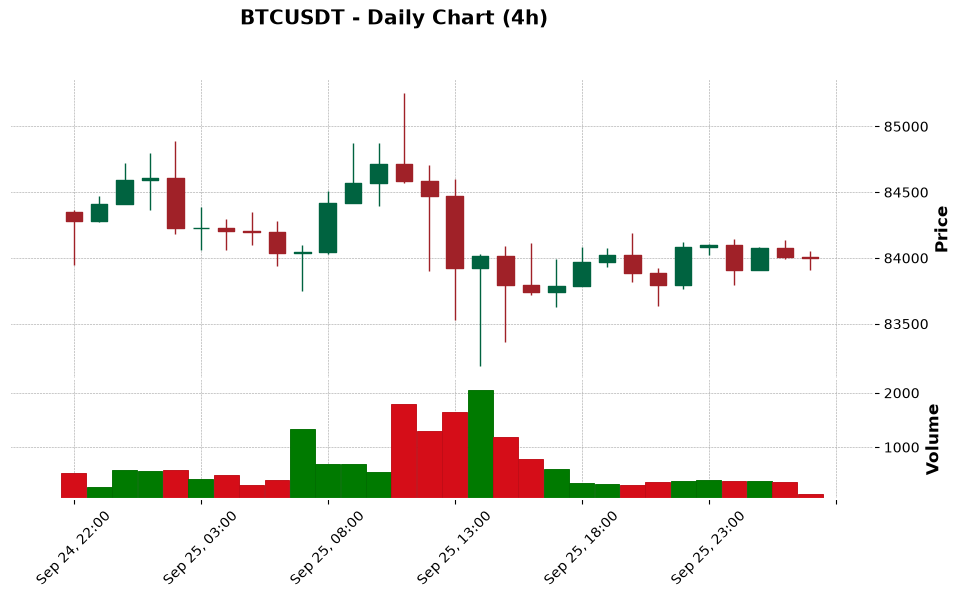

In [6]:
import sys
import os

sys.path.append(os.path.abspath(".."))

import pandas as pd
import mplfinance as mpf
from app.services.market_data import MarketDataService
from app.services.charts import chart_gen

service = MarketDataService()
df_btc = service.cleaned_klines(symbol="BTCUSDT", interval="1h", limit=30)

chart_gen(df_btc, title="BTCUSDT - Daily Chart (4h)")
    
    

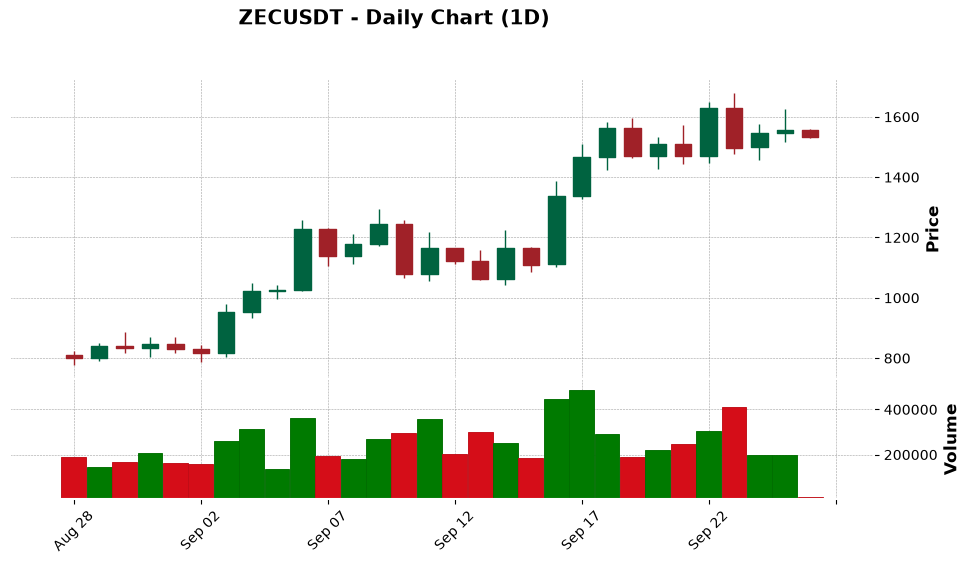

In [11]:
import sys
import os

sys.path.append(os.path.abspath(".."))

import pandas as pd
import mplfinance as mpf
from app.services.market_data import MarketDataService
from app.services.charts import chart_gen
from app.services.top_50_alts import TOP_50_ALTS

service = MarketDataService()
df_btc = service.cleaned_klines(symbol="ZECUSDT", interval="1D", limit=30)

chart_gen(df_btc, title="ZECUSDT - Daily Chart (1D)")